In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [97]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Шаг 1 - анализ данных

In [8]:
print('Размер датасета: ', df.shape)

Размер датасета:  (10000, 14)


In [7]:
df.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [9]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Видим, что колонки _RowNumber_, _CustomerId_, _Geography_, _Gender_, _Tenure_, _NumOfProducts_, _HasCrCard_, _IsActiveMember_ относятся к категориальным переменным. Остальные колонки - _CreditScore_, _Age_, _Balance_, _EstimatedSalary_ - это количественные переменные.

Создадим два списка, куда запишем колонки для раздельного анализа.

In [104]:
categorial_columns = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
numer_columns = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

In [10]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Пропусков нет, что радует, т.к. не нужно будет проводить этап обработки пропусков.

Построим графики для категориальных переменных, запишем наблюдения касаемо этих признаков.

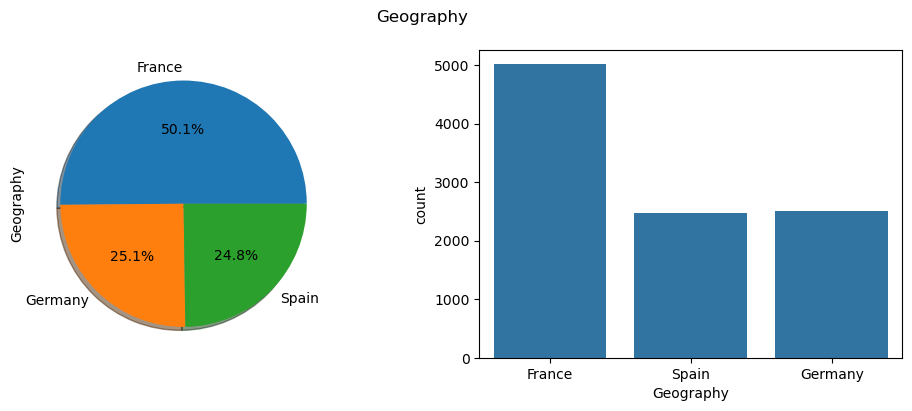

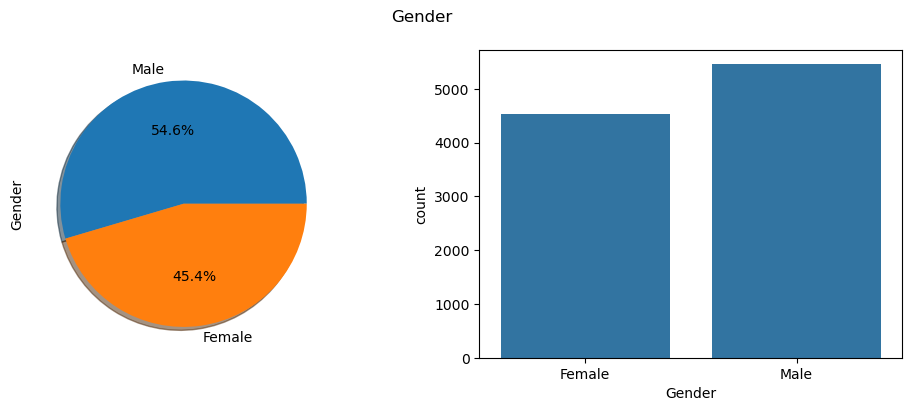

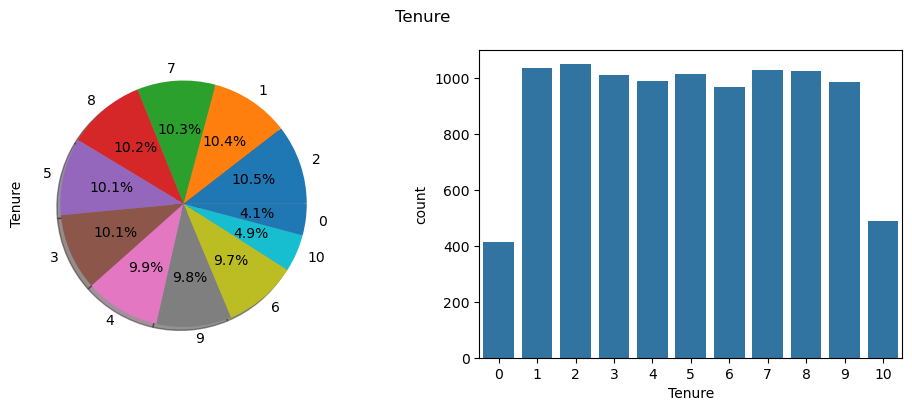

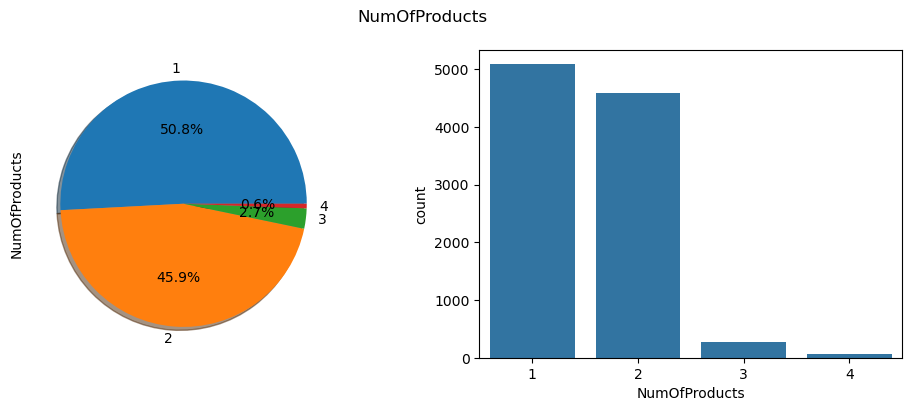

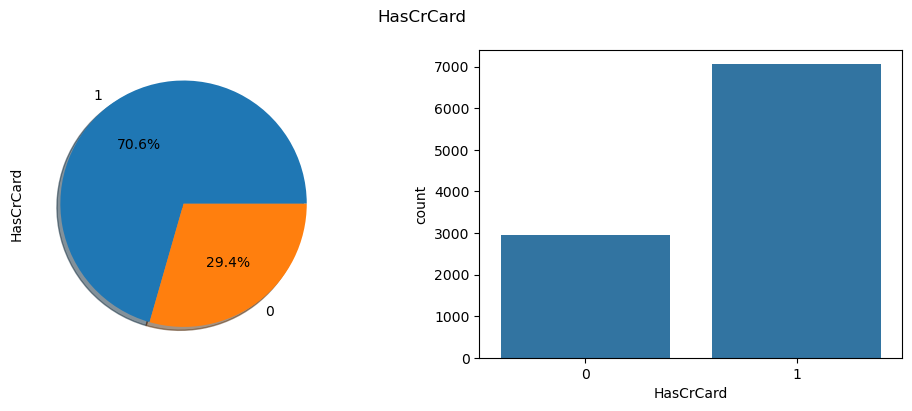

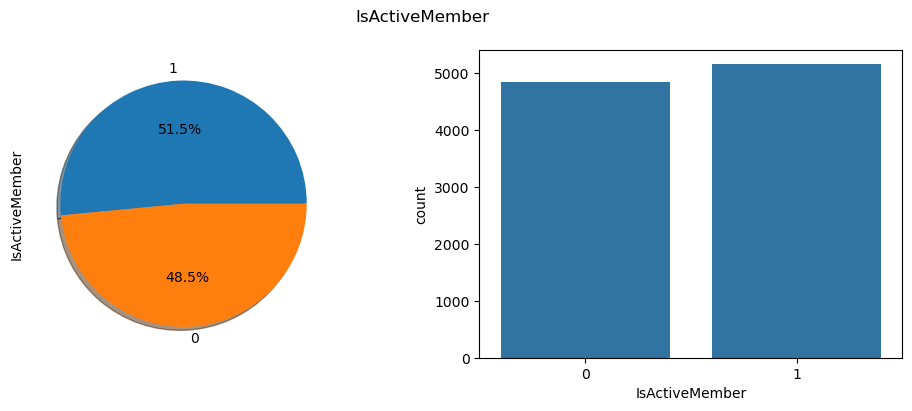

In [112]:
for column in categorial_columns:
    f,ax=plt.subplots(1,2,figsize=(12,4))
    df[column].value_counts().plot.pie(autopct='%1.1f%%',ax=ax[0],shadow=True)
    ax[0].set_ylabel(f'{column}')
    sns.countplot(x=column,data=df,ax=ax[1])
    plt.suptitle(f'{column}')
    plt.show()

1) Большая часть клиентов банка - жители Франции. Количество жителей Германии и Испании примерно одинаковы. 
2) Распределение полов примерно равномерное. Нет сильного перекоса к какому-то одному полу.
3) _Tenure_ - сколько клиент работает с банком в годах - в целом, наблюдается равномерное распределение, однако есть просадки в 0 и 10.
4) Большинство клиентов имеют 1 или 2 продукта банка, есть небольшое количество клиентов кто имеет 3 или 4 продукта.
5) Около 70% клиентов имеют кредитную карту.
6) Разбиение на активных и неактивных клиентов примерно 50:50.

По графикам В категориальных признаках каких-то аномалий выявить не удалось. 

Посмотрим теперь на целевую переменную  - _Exited_ \
1 - клиент ушел \
0 - клиент остался.

Видим, что есть перекос данных в сторону 0, поэтому в будущем, при разделении выборки на обучаюущую и тестовую, нужно будет учесть этот факт.

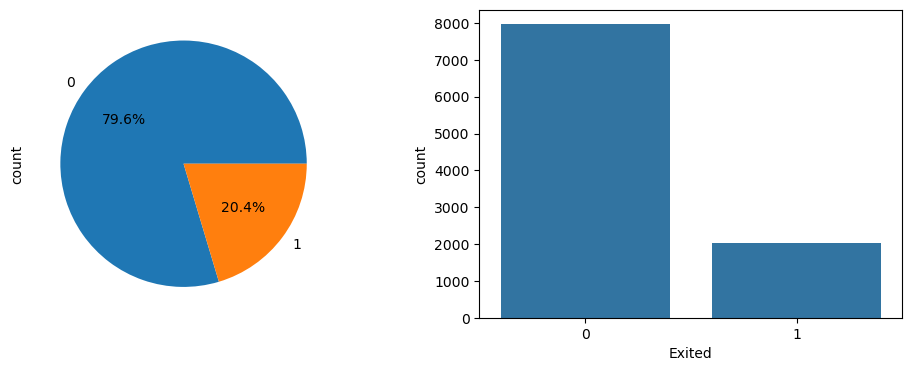

In [33]:
ff, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Exited'].value_counts().plot.pie(ax=ax[0], autopct='%1.1f%%')
sns.countplot(data=df, x='Exited', ax=ax[1])
plt.show()

Теперь построим графики (гистограммы) распределения оставшихся трех признаков (количественных)

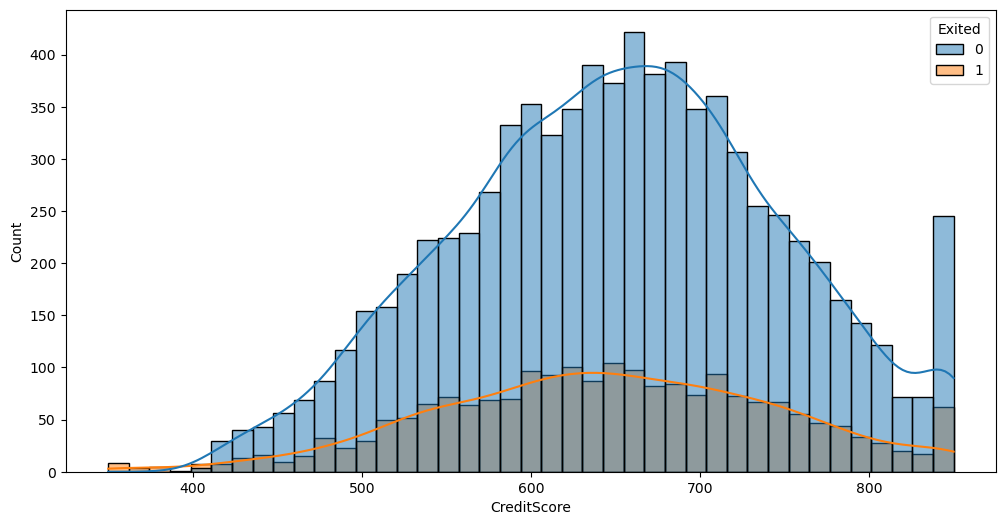

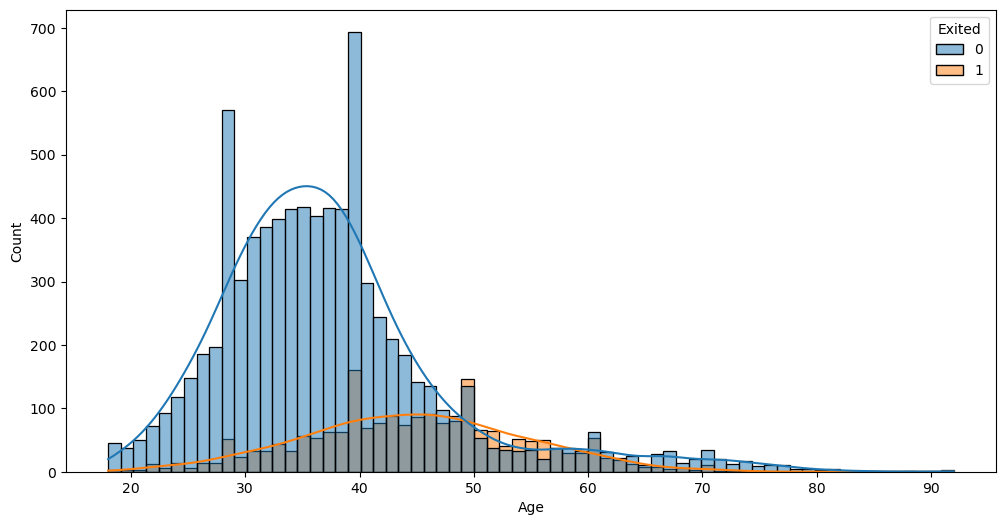

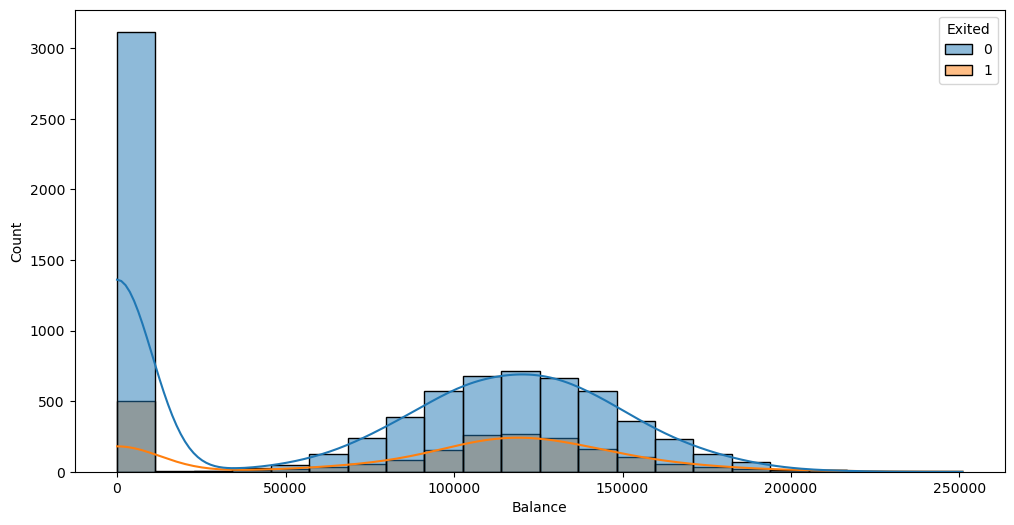

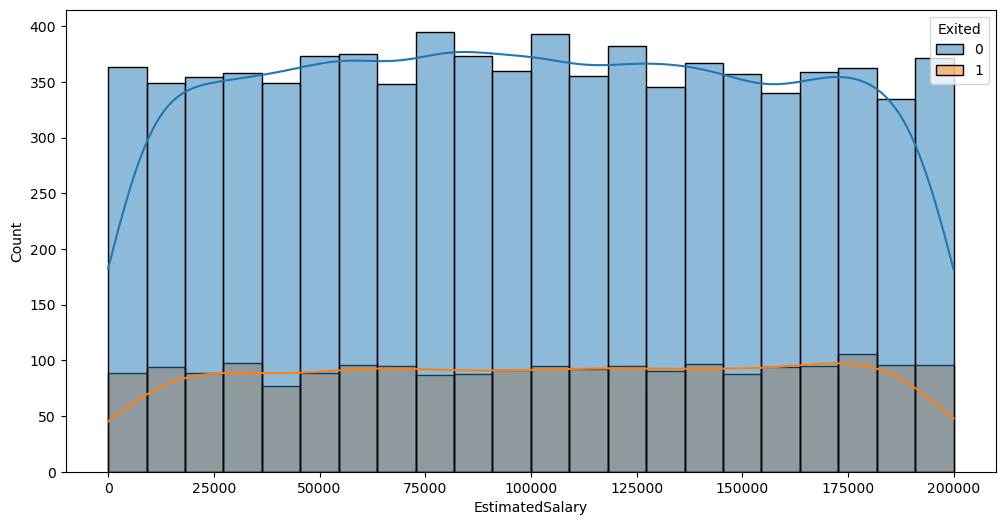

In [106]:
for col in numer_columns:
    ff, ax = plt.subplots(figsize=(12, 6))
    sns.histplot(data=df, x=col, hue='Exited', kde=True)
    plt.show()

1) Можно сказать, что распределение признаков для обоих классов примерно одинаковые.
2) Большая часть клиентов имеет возраст около 28 и 40 лет - есть два пика на гистограмме.
3) На графике баланса видим, что более 30% всех клиентов не имеют денег на счету.

Построим тепловую карту корреляции между признаками и целевой переменной.

Видим, что наибольшая корреляция с целевой переменной достигается признаком _Age_ = 0.29. На самом деле это немного и сложно делать большие выводы из этого.

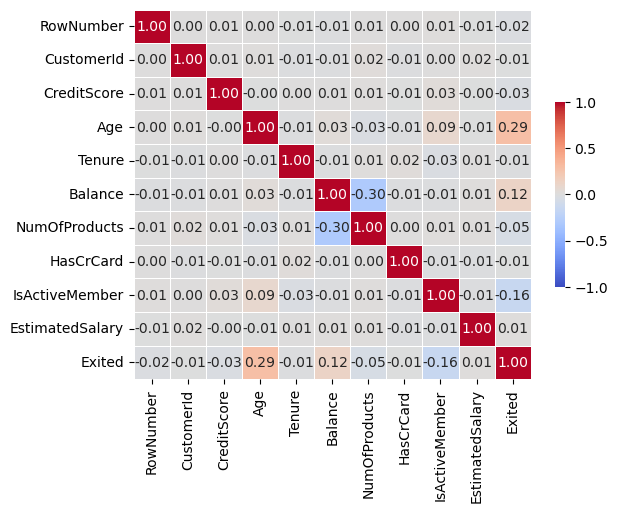

In [45]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr,
      annot=True,
      fmt=".2f",
      cmap='coolwarm',
      linewidths=.5,
      cbar_kws={'shrink': .5},
      vmax=1, vmin=-1
      )
plt.show()

# Шаг 2 - препроцессинг данных

Удалим три колонки - 'RowNumber', 'CustomerId', 'Surname'. Дополнительной информации они не дают.

In [78]:
df_dropped = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

Обработаем категориальные признаки. У нас остались 'Geography', 'Gender'. По размерам они небольшие, поэтому воспользуемся one-hot encoding.

In [84]:
df_dropped = pd.get_dummies(df_dropped, columns = ['Geography', 'Gender'], drop_first=True)
bool_cols = df_dropped.select_dtypes(include='bool').columns
df_dropped[bool_cols] = df_dropped[bool_cols].astype(int)

In [86]:
df_dropped.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0


В принципе, можно попробовать нормировать колонки _Balance_ и _EstimatedSalary_, т.к. их абсолютные значения могут сильно повлиять на обучение некоторых моделей машинного обучения. 

Но пока этого делать не будем; если будут подозрения, что сильно влияет, то нормируем.

Разделим выборку на тестовую и обучающую. Включим флаг stratify, т.к. мы помним, что у нас дисбаланс классов.

In [178]:
X = df_dropped.drop(columns='Exited')
Y = df_dropped['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, Y, 
                                                    random_state=42, 
                                                    shuffle=True, 
                                                    stratify=Y, 
                                                    test_size=0.2,
                                                    train_size=0.8)

print(X_train.shape, X_test.shape)

(8000, 11) (2000, 11)


# Шаг 3 - построение модели

Существует множество методов для решения бинарной классификации. В данном тестовом задании не будем пробовать все, попробуем три метода, которые могут быть как-то интерпретированы - логистическая регрессия, случайный лес и xgboost.

План следующий:
1) Строим модель с параметрами по умолчанию.
2) Пытаемся подобрать гиперпараметры с помощью optuna.
3) Анализируем модель и пытаемся ее интерпретировать

В качестве метрик будем использовать accuracy, f1, precision, recall

### 3.1 Логистическая регрессия

In [179]:
def metric_scores(y_test, y_pred):
    print('F1 score: ', round(f1_score(y_test, y_pred), 3))
    print('Accuracy: ', round(accuracy_score(y_test, y_pred), 3))
    print('Precision: ', round(precision_score(y_test, y_pred), 3))
    print('Recall: ', round(recall_score(y_test, y_pred), 3))

In [180]:
logreg = LogisticRegression(penalty='l2', fit_intercept=True)
_ = logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
metric_scores(y_test, y_pred)

F1 score:  0.119
Accuracy:  0.792
Precision:  0.438
Recall:  0.069


In [212]:
def objective_logreg(trial, X, y, n_splits=5, metric='f1'):
    params = {
        'C': trial.suggest_float('C', 1e-4, 100, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'penalty': trial.suggest_categorical('penalty', ['l2']),
        'max_iter': trial.suggest_int('max_iter', 100, 1000)}
    
    model = make_pipeline(
        LogisticRegression(**params, random_state=42))
    
    scores = cross_val_score(model, X, y, cv=n_splits, scoring=metric)
    return scores.mean()

In [213]:
def optimize(objective, X, y, n_trials=50, metric='f1'):
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X, y, n_splits=5, metric=metric), n_trials=n_trials)
    
    print(f"Лучшие параметры: {study.best_params}")
    print(f"Лучшая {metric}: {round(study.best_value, 4)}")
    return study.best_params

In [214]:
best_params = optimize(objective_logreg, X_train, y_train, n_trials=25)

[I 2025-05-02 18:15:45,385] A new study created in memory with name: no-name-5314aad0-ef40-4532-83dd-553a1249d171
[I 2025-05-02 18:15:46,369] Trial 0 finished with value: 0.32164757014382095 and parameters: {'C': 18.9575584741968, 'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 422}. Best is trial 0 with value: 0.32164757014382095.
[I 2025-05-02 18:15:51,172] Trial 1 finished with value: 0.0 and parameters: {'C': 42.800229894570876, 'solver': 'saga', 'penalty': 'l2', 'max_iter': 844}. Best is trial 0 with value: 0.32164757014382095.
[I 2025-05-02 18:15:52,957] Trial 2 finished with value: 0.0 and parameters: {'C': 0.06814910205038134, 'solver': 'saga', 'penalty': 'l2', 'max_iter': 304}. Best is trial 0 with value: 0.32164757014382095.
[I 2025-05-02 18:15:55,968] Trial 3 finished with value: 0.0 and parameters: {'C': 0.13174424677360755, 'solver': 'saga', 'penalty': 'l2', 'max_iter': 522}. Best is trial 0 with value: 0.32164757014382095.
[I 2025-05-02 18:15:58,901] Trial 4 finished with

Лучшие параметры: {'C': 18.9575584741968, 'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 422}
Лучшая f1: 0.3216


In [215]:
best_model = LogisticRegression(**best_params)
_ = best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
metric_scores(y_test, y_pred)

F1 score:  0.294
Accuracy:  0.81
Precision:  0.608
Recall:  0.194


In [217]:
np.unique(y_pred)

array([0, 1], dtype=int64)

Подобрав наилучшие параметры на кросс-валидации видим, что качество стало лучше. Посмотрим какие признаки имеют наибольший вес.

In [216]:
impact = map(lambda x: round(x, 5), best_model.coef_.tolist()[0])
importance = dict(zip(X.columns.tolist(), impact))

for k, v in sorted(importance.items(), key=lambda x: x[-1], reverse=True):
    print(f'importance {k} ---> {v}')

importance Geography_Germany ---> 0.77848
importance Age ---> 0.05949
importance Balance ---> 0.0
importance EstimatedSalary ---> -0.0
importance CreditScore ---> -0.00341
importance Tenure ---> -0.02641
importance Geography_Spain ---> -0.16096
importance HasCrCard ---> -0.1967
importance NumOfProducts ---> -0.24678
importance Gender_Male ---> -0.63552
importance IsActiveMember ---> -1.08483


Какие выводы можно сделать?

1) Активные пользователи с гораздо меньшей вероятностью уйдут. Это логично, т.к. они вовлечены в инфраструктуру банка.
2) По неизвестной причине жители Германии имеют высокий шанс уйти от банка.
3) Мужчины менее склонны к смене банка.
4) Наличие кредитной карты или иных продуктов банка снижает риск ухода от банка.
5) Баланс на счете и вероятная зарплата не вносят никакого вклада в риск оттока клиента. Сложно сказать - нормально ли это. Чтобы сделать какой-то осмысленный вывод нужно понять особенности банка.

Итог: в целом логистическая регрессия неплохо справилась, однако есть несколько аномальных результатов (с жителями Германии и доходами). Эти признаки нужно изучать внимательнее.

### 3.1 Случайный лес

In [200]:
rf_model = RandomForestClassifier()
_ = rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
metric_scores(y_test, y_pred)

F1 score:  0.59
Accuracy:  0.865
Precision:  0.773
Recall:  0.477


In [219]:
def objective_rf(trial, X, y, n_splits=5, metric='f1'):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 15, step=3),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, step=2),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
    }
    model_trial = make_pipeline(
        RandomForestClassifier(**params, random_state=42))
    
    scores = cross_val_score(model_trial, X, y, cv=n_splits, scoring=metric)
    return scores.mean()

In [221]:
best_params = optimize(objective_rf, X_train, y_train, n_trials=25)

[I 2025-05-02 18:17:41,939] A new study created in memory with name: no-name-7c4fc826-dd1d-4960-92c8-3949ba405d85
[I 2025-05-02 18:17:44,665] Trial 0 finished with value: 0.6040155323444578 and parameters: {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 6, 'max_features': 0.3, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6040155323444578.
[I 2025-05-02 18:17:50,051] Trial 1 finished with value: 0.6058653396892018 and parameters: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 4, 'max_features': 0.3, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6058653396892018.
[I 2025-05-02 18:17:55,378] Trial 2 finished with value: 0.6047409122245094 and parameters: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 14, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6058653396892018.
[I 2025-05-02 18:18:12,146] Trial 3 finished with value: 0.6204429520368325 and parameters: {'n_estimators': 500, 'max_depth':

Лучшие параметры: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 16, 'max_features': 'log2', 'class_weight': 'balanced'}
Лучшая f1: 0.6293


In [222]:
best_model = RandomForestClassifier(**best_params)
_ = best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
metric_scores(y_test, y_pred)

F1 score:  0.632
Accuracy:  0.846
Precision:  0.615
Recall:  0.649


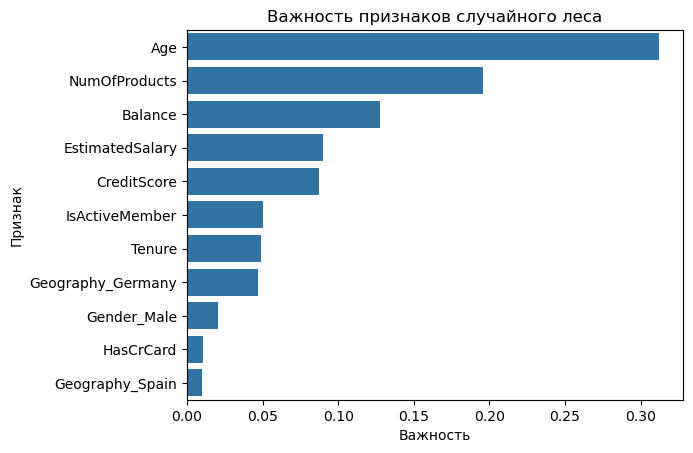

In [232]:
features = pd.DataFrame({'Признак': X.columns, 'Важность': best_model.feature_importances_}).sort_values('Важность', ascending=False)

sns.barplot(data=features, x='Важность', y='Признак')
plt.title('Важность признаков случайного леса')
plt.show()


Что видим?

1) Наиболее важным признаком оказался _Age_. Сложно это как-то объяснить. Хотя можно вспомнить, что именно с _Age_ была самая высокая корреляция.
2) После возраста по важности идут _NumOfProducts_, _Balance_, _EstimatedSalary_, _CreditScore_ - в целом их важность более ясна. Финансовые характеристики клиента могут на его решение о смене банка.

Попробуем теперь построить одно из деревьев решения в случайном лесе. Т.к. лучшая модель имеет глубину 12, то получится картинка, на которой ничего не видно. Я обучу еще одну модель леса, но задам максимальную глубину равной 3. Качество точно изменится и не факт, что в лучшую сторону, но зато визуализируем результат обучения. 

In [245]:
params = {'n_estimators': 300,
         'max_depth': 3,
         'min_samples_split': 16,
         'max_features': 'log2',
         'class_weight': 'balanced'}

tmp_model = RandomForestClassifier(**params)
_ = tmp_model.fit(X_train, y_train)
y_pred = tmp_model.predict(X_test)
metric_scores(y_test, y_pred)

F1 score:  0.582
Accuracy:  0.786
Precision:  0.484
Recall:  0.73


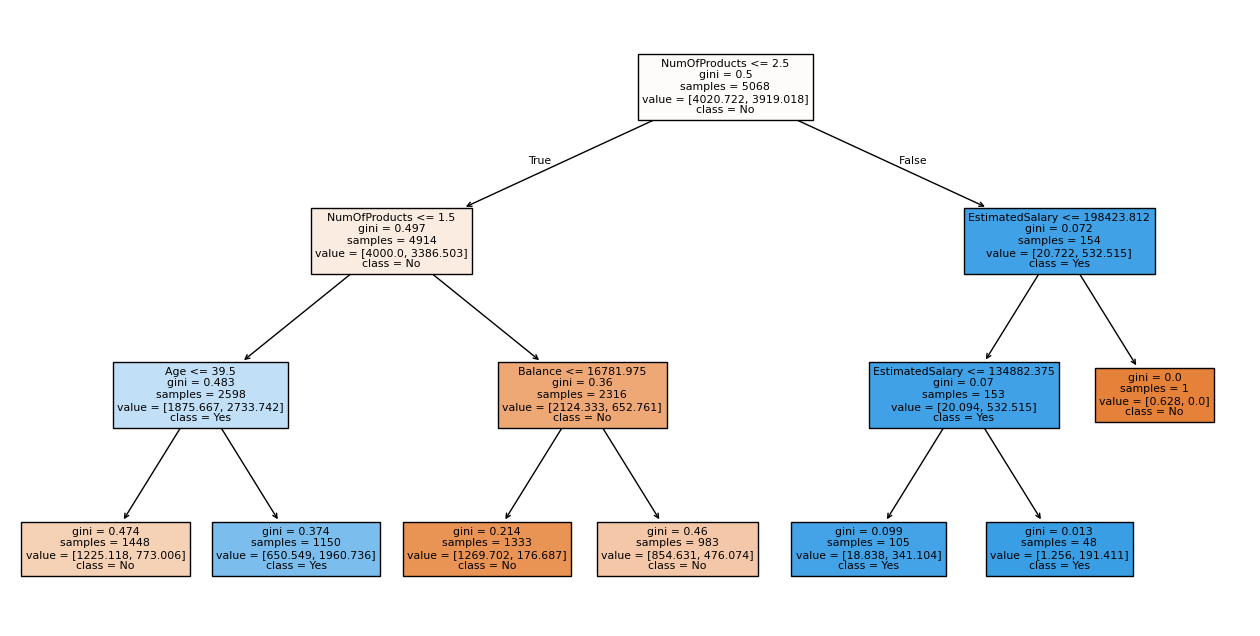

In [250]:
from sklearn.tree import plot_tree

class_name = ['No', 'Yes']
plt.figure(figsize=(16,8))
plot_tree(tmp_model.estimators_[0], max_depth=3, filled=True, feature_names=X.columns, class_names=class_name)
plt.show()

### 3.3 Xgboost

In [251]:
xgb_model = xgb.XGBClassifier()
_ = xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
metric_scores(y_test, y_pred)

F1 score:  0.565
Accuracy:  0.849
Precision:  0.683
Recall:  0.482


In [257]:
def objective_xgb(trial, X, y, n_splits=5, metric='f1'):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "eval_metric": "logloss"
    }
    model_trial = make_pipeline(
        xgb.XGBClassifier(**params, random_state=42))
    
    scores = cross_val_score(model_trial, X, y, cv=n_splits, scoring=metric)
    return scores.mean()

In [258]:
best_params = optimize(objective_xgb, X_train, y_train, n_trials=25)

[I 2025-05-02 18:54:25,325] A new study created in memory with name: no-name-72db2e5d-e25c-42dc-b0a8-ce4ed13ef01d
[I 2025-05-02 18:54:26,737] Trial 0 finished with value: 0.5799934571066698 and parameters: {'n_estimators': 309, 'max_depth': 7, 'learning_rate': 0.01439464459308981, 'subsample': 0.6335739253403968, 'gamma': 4.300580357979134, 'min_child_weight': 2}. Best is trial 0 with value: 0.5799934571066698.
[I 2025-05-02 18:54:27,673] Trial 1 finished with value: 0.5778196785122071 and parameters: {'n_estimators': 172, 'max_depth': 6, 'learning_rate': 0.028642773782098823, 'subsample': 0.9410045905357455, 'gamma': 1.0179572798602232, 'min_child_weight': 2}. Best is trial 0 with value: 0.5799934571066698.
[I 2025-05-02 18:54:28,743] Trial 2 finished with value: 0.5723767102232376 and parameters: {'n_estimators': 317, 'max_depth': 4, 'learning_rate': 0.01428622336153068, 'subsample': 0.6146625794929365, 'gamma': 1.1084281305022226, 'min_child_weight': 10}. Best is trial 0 with value:

Лучшие параметры: {'n_estimators': 455, 'max_depth': 9, 'learning_rate': 0.026783435177044575, 'subsample': 0.7190131125306227, 'gamma': 2.8991645087874116, 'min_child_weight': 2}
Лучшая f1: 0.5999


In [259]:
best_model = xgb.XGBClassifier(**best_params)
_ = best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
metric_scores(y_test, y_pred)

F1 score:  0.594
Accuracy:  0.865
Precision:  0.762
Recall:  0.486


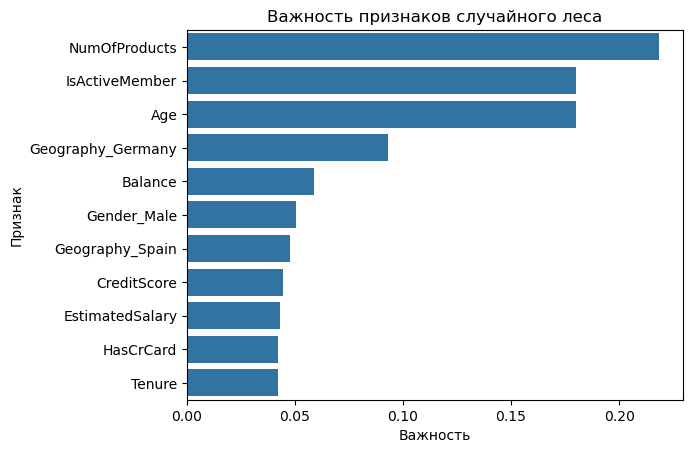

In [260]:
features = pd.DataFrame({'Признак': X.columns, 'Важность': best_model.feature_importances_}).sort_values('Важность', ascending=False)

sns.barplot(data=features, x='Важность', y='Признак')
plt.title('Важность признаков случайного леса')
plt.show()

Чем отличается xgboost?

1) Наиболее важным признаком оказался признак _NumOfProducts_. В целом подобная картина наблюдалась и у предыдущих моделей, они выделяли _NumOfProducts_ как один из важных признаков.
2) После _NumOfProducts_ по важности идут _Age_ и _isActiveMember_. С _isActiveMember_ тоже понятно - раз активный пользователь, значит пользуется продуктами банка, неаткивный - возможно пробует или уже использует продукты других банков. Про _Age_ опять же сложно сказать.

Сделаем ту же операцию, что и со Случайным лесом - построим новый xgboost с меньшей глубиной деревьев и визуализируем. 

In [263]:
params = {'n_estimators': 455,
         'max_depth': 3,
         'learning_rate': 0.026783435177044575,
         'subsample': 0.7190131125306227,
         'gamma': 2.8991645087874116,
         'min_child_weight': 2}

tmp_model = xgb.XGBClassifier(**params)
_ = tmp_model.fit(X_train, y_train)
y_pred = tmp_model.predict(X_test)
metric_scores(y_test, y_pred) #Интересно, что изменив только глубину качество сразу улучшилось по сравнению с "best_model"

F1 score:  0.612
Accuracy:  0.872
Precision:  0.793
Recall:  0.499


In [287]:
from supertree import SuperTree

st = SuperTree(tmp_model, X_train, Y, target_names=class_name)
st.show_tree(which_tree=453) 


## Выводы

1) Был проведен довольно простой анализ данных, предобработка данных. Далее были построены три модели, которые я попытался интерпретировать.
2) Наилучшее качество показали Случайный лес и Xgboost. Логистическая регрессия показала худшее качество.

#### Как можно улучшить решение?

1) Если мы хотим добиться лучшего качества, то, конечно, стоит перебрать гораздо больше комбинация гиперпараметров.
2) Чтобы получить больше данных о принятии решения той или иной моделью можно попробовать провести пермутационные тесты, чтобы оценить реалистичный вклад тех или иных признаков.